# Threshold Tuning — Custom CNN (Skin Cancer Classifier)

**Goal:** load the trained Custom CNN and the val set, then sweep the decision threshold
(instead of the default 0.5) to find where the model performs best — including the threshold
that produces the **fewest total misclassified images**.

**What this notebook does, in order:**
1. Reload config + rebuild the val set (same 224×224 pipeline used in training)
2. Load the saved **Custom CNN** model from disk (no retraining)
3. Run inference **once** to get predicted probabilities for every test image
4. Sweep thresholds from 0.01 to 0.99 against those same probabilities (fast — no re-inference per threshold)
5. Plot **misclassified count vs. threshold** and report the minimum
6. **Important caveat, read before trusting the "best" threshold blindly:** minimizing total
   misclassifications (FP + FN) treats a missed malignant case exactly the same as a false alarm.
   In a cancer-screening context those are not equally costly — a missed malignant case (false
   negative) is worse than an unnecessary follow-up (false positive). So alongside the literal
   min-misclassification threshold, this notebook also reports the F1-optimal threshold and a
   recall-prioritized (F2) threshold, so you can see the tradeoff before picking one.
7. Confusion matrix + misclassified image grid at the chosen threshold


## 1. Setup — imports & seeds

In [1]:
import os, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Config

Same paths/settings as the training notebook — edit `DATASET_PATH` and `OUTPUT_DIR` if yours differ.

In [23]:
import zipfile
import os

DATASET_PATH = "/content/"  # Ensure DATASET_PATH is defined if not already
zip_file_path = "/content/val_set.zip"
extraction_path = DATASET_PATH

# Create the extraction directory if it doesn't exist
if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

'/content/val_set.zip' unzipped to '/content/'


In [74]:
# ==================== EDIT THESE IF NEEDED ====================
DATASET_PATH = "/content/"
OUTPUT_DIR   = "/content/model_artifacts"
MODEL_PATH   = "/content/Custom_CNN.keras"
# ================================================================

SPLIT_DIRNAMES = {"test": "val_set"}
CLASS_NAMES = ["benign", "malignant"]   # index 0 = benign, index 1 = malignant (positive class)
POSITIVE_CLASS = "malignant"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

TEST_DIR = os.path.join(DATASET_PATH, SPLIT_DIRNAMES["test"])
for c in CLASS_NAMES:
    p = os.path.join(TEST_DIR, c)
    assert os.path.isdir(p), f"Missing expected folder: {p}"
print("val folder OK:", TEST_DIR)

val folder OK: /content/val_set


## 4. Load the test data

Same file-listing approach used when the models were originally evaluated, so the numbers here
line up with your earlier results.

In [75]:
def list_images_recursive(base_dir):
    image_paths = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    return image_paths

test_files = list_images_recursive(val_DIR)
test_labels = []
for p in test_files:
    parent_dir_name = os.path.basename(os.path.dirname(p))
    label = 1 if parent_dir_name == POSITIVE_CLASS else 0
    test_labels.append(label)

print(f"val images: {len(test_files)} | class counts: {Counter(test_labels)}")
y_true = np.array(test_labels)


val images: 1100 | class counts: Counter({1: 550, 0: 550})


In [76]:
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # stays in [0, 255] -- matches training pipeline
    return img, label

def make_dataset(files, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

test_ds = make_dataset(test_files, test_labels, training=False)


## 5. Load the trained Custom CNN

Tries the final saved model first, falls back to the best checkpoint saved during training by
`ModelCheckpoint` if the final save isn't found.

In [77]:
candidate_paths = [
    "/content/Custom_CNN.keras",
]

model_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if model_path is None:
    raise FileNotFoundError(
        f"Could not find the Custom CNN model in any of: {candidate_paths}. "
        "Edit `candidate_paths` to point at your saved model file."
    )

custom_cnn = keras.models.load_model(model_path)
print("Loaded model from:", model_path)


Loaded model from: /content/Custom_CNN.keras


## 6. Run inference once

Predicted probabilities are computed a single time and reused for every threshold in the sweep
below — thresholding is just comparing numbers, it doesn't need the model to run again.

In [78]:
t0 = time.time()
y_prob = custom_cnn.predict(test_ds, verbose=0).ravel()
print(f"Inference time: {time.time()-t0:.1f}s over {len(y_prob)} images")

print(f"Predicted probability range: [{y_prob.min():.3f}, {y_prob.max():.3f}]")


Inference time: 5.1s over 1100 images
Predicted probability range: [0.018, 1.000]


## 7. Baseline — default threshold (0.5)

In [73]:
def metrics_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "misclassified": fp + fn,
    }

baseline = metrics_at_threshold(y_true, y_prob, 0.5)
print("=== Threshold = 0.49 (default) ===")
for k, v in baseline.items():
    print(f"  {k:14s}: {v}")


=== Threshold = 0.49 (default) ===
  threshold     : 0.34
  accuracy      : 0.8245454545454546
  precision     : 0.7902439024390244
  recall        : 0.8836363636363637
  f1            : 0.8343347639484978
  tn            : 421
  fp            : 129
  fn            : 64
  tp            : 486
  misclassified : 193


## 8. Threshold sweep

Every threshold from 0.01 to 0.99 (step 0.01) evaluated against the same fixed set of predicted
probabilities from Section 6.

In [34]:
thresholds = np.arange(0.01, 1.00, 0.01)
sweep_rows = [metrics_at_threshold(y_true, y_prob, t) for t in thresholds]
sweep_df = pd.DataFrame(sweep_rows)
sweep_df.head()


,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp,misclassified
0,0.01,0.500000,0.500000,1.0,0.666667,0,550,0,550,550
1,0.02,0.504545,0.502283,1.0,0.668693,5,545,0,550,545
2,0.03,0.535455,0.518379,1.0,0.682806,39,511,0,550,511
3,0.04,0.570909,0.538160,1.0,0.699746,78,472,0,550,472
4,0.05,0.594545,0.552209,1.0,0.711514,104,446,0,550,446


## 9. Misclassified count vs. threshold

This directly answers "at which threshold are misclassified images fewest" — the minimum point
on this curve.

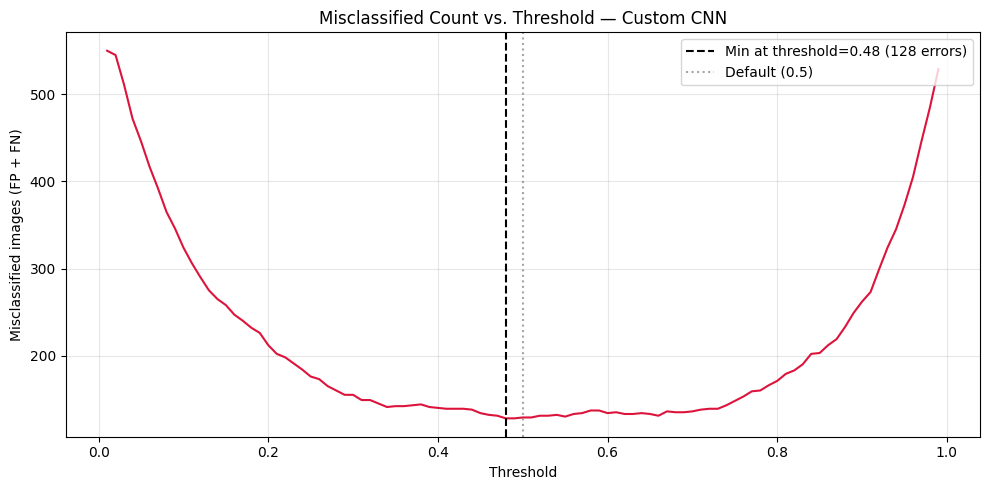

Minimum misclassified count: 128 images, achieved at threshold(s): [0.48, 0.49]
(out of 1100 total test images)


In [35]:
min_row = sweep_df.loc[sweep_df["misclassified"].idxmin()]
min_misclass_threshold = min_row["threshold"]
min_misclass_count = int(min_row["misclassified"])

# In case of ties, report the full tied set too
tied = sweep_df[sweep_df["misclassified"] == min_row["misclassified"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df["threshold"], sweep_df["misclassified"], color='crimson', linewidth=1.5)
ax.axvline(min_misclass_threshold, color='black', linestyle='--',
           label=f'Min at threshold={min_misclass_threshold:.2f} ({min_misclass_count} errors)')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Misclassified images (FP + FN)')
ax.set_title('Misclassified Count vs. Threshold — Custom CNN')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Minimum misclassified count: {min_misclass_count} images, "
      f"achieved at threshold(s): {sorted(tied['threshold'].round(2).tolist())}")
print(f"(out of {len(y_true)} total test images)")


## 10. Where that threshold sits relative to precision/recall/F1

The threshold that minimizes total errors is not automatically the "best" threshold for this
use case — this plot shows what you'd be trading off if you use it.

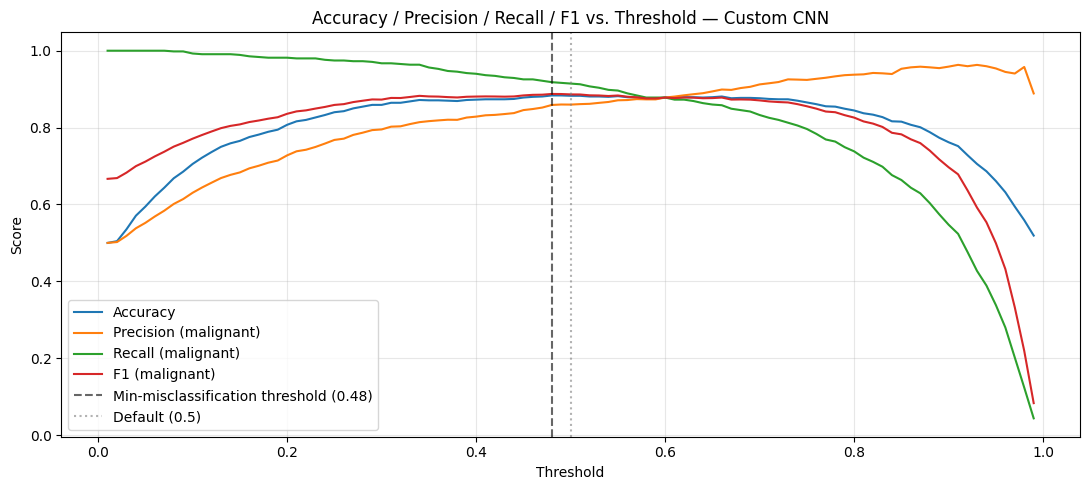

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep_df["threshold"], sweep_df["accuracy"], label="Accuracy")
ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision (malignant)")
ax.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall (malignant)")
ax.plot(sweep_df["threshold"], sweep_df["f1"], label="F1 (malignant)")
ax.axvline(min_misclass_threshold, color='black', linestyle='--', alpha=0.6,
           label=f'Min-misclassification threshold ({min_misclass_threshold:.2f})')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Accuracy / Precision / Recall / F1 vs. Threshold — Custom CNN')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Three candidate thresholds, side by side

- **Min-misclassification** — literally fewest total wrong predictions (what you asked for)
- **F1-optimal** — best balance of precision/recall
- **F2-optimal (recall-prioritized)** — weights recall higher than precision, i.e. favors catching
  malignant cases over avoiding false alarms; usually the more clinically defensible choice for a
  screening tool

In [37]:
def f_beta(precision, recall, beta):
    beta2 = beta ** 2
    numerator = (1 + beta2) * precision * recall
    denominator = (beta2 * precision + recall)

    # Use np.where to handle the case where the denominator is zero (or both precision/recall are zero)
    # If denominator is 0, the result should be 0.0 for that element; otherwise, perform the calculation.
    # Adding a small epsilon (1e-12) to the denominator for numerical stability when it's not zero.
    result = np.where(denominator == 0, 0.0, numerator / (denominator + 1e-12))
    return result

sweep_df["f2"] = f_beta(sweep_df["precision"], sweep_df["recall"], beta=2)

f1_optimal = sweep_df.loc[sweep_df["f1"].idxmax()]
f2_optimal = sweep_df.loc[sweep_df["f2"].idxmax()]

candidates_df = pd.DataFrame({
    "Min-misclassification": min_row,
    "F1-optimal": f1_optimal,
    "F2-optimal (recall-priority)": f2_optimal,
}).T[["threshold", "accuracy", "precision", "recall", "f1", "fp", "fn", "misclassified"]]
candidates_df = candidates_df.round(4)
candidates_df


,threshold,accuracy,precision,recall,f1,fp,fn,misclassified
Min-misclassification,0.48,0.8836,0.8588,0.9182,0.8875,83.0,45.0,128.0
F1-optimal,0.48,0.8836,0.8588,0.9182,0.8875,83.0,45.0,128.0
F2-optimal (recall-priority),0.34,0.8718,0.8141,0.9636,0.8826,121.0,20.0,141.0


## 12. Confusion matrix at the min-misclassification threshold

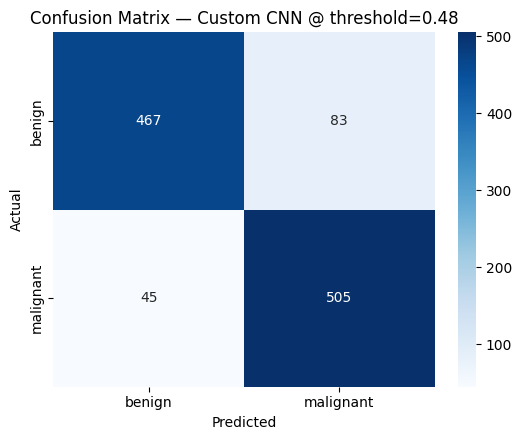

True Negatives  (correct benign)    : 467
False Positives (benign -> malignant): 83
False Negatives (malignant -> benign): 45
True Positives  (correct malignant) : 505
Miss rate at this threshold: 8.2% of malignant cases missed


In [38]:
y_pred_best = (y_prob >= min_misclass_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix — Custom CNN @ threshold={min_misclass_threshold:.2f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct benign)    : {tn}")
print(f"False Positives (benign -> malignant): {fp}")
print(f"False Negatives (malignant -> benign): {fn}")
print(f"True Positives  (correct malignant) : {tp}")
print(f"Miss rate at this threshold: {fn/(y_true==1).sum()*100:.1f}% of malignant cases missed")


## 13. Misclassified images at this threshold

Misclassified: 128 / 1100


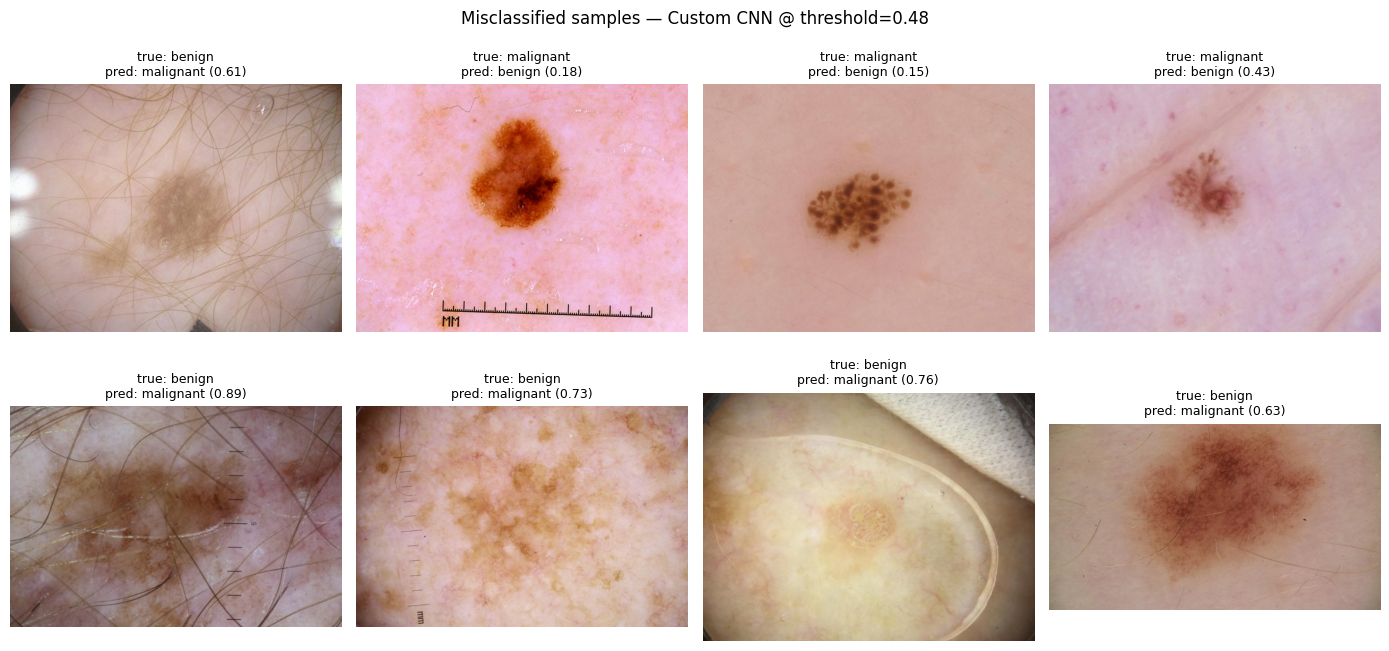

In [39]:
wrong_idx = np.where(y_pred_best != y_true)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_true)}")

n_show = min(8, len(wrong_idx))
sample_idx = np.random.RandomState(SEED).choice(wrong_idx, size=n_show, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), sample_idx):
    img = tf.io.read_file(test_files[idx])
    img = tf.image.decode_jpeg(img, channels=3)
    ax.imshow(img.numpy())
    true_lbl = CLASS_NAMES[y_true[idx]]
    pred_lbl = CLASS_NAMES[y_pred_best[idx]]
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl} ({y_prob[idx]:.2f})", fontsize=9)
    ax.axis('off')
for ax in axes.ravel()[n_show:]:
    ax.axis('off')
plt.suptitle(f"Misclassified samples — Custom CNN @ threshold={min_misclass_threshold:.2f}")
plt.tight_layout()
plt.show()


## 14. Summary

In [40]:
print("="*70)
print("THRESHOLD TUNING SUMMARY -- CUSTOM CNN")
print("="*70)
print(f"Test images: {len(y_true)} ({(y_true==0).sum()} benign, {(y_true==1).sum()} malignant)")
print(f"Model file used: {model_path}")
print()
print(f"Default threshold (0.50): {baseline['misclassified']} misclassified "
      f"(accuracy={baseline['accuracy']:.4f}, recall={baseline['recall']:.4f})")
print(f"Min-misclassification threshold: {min_misclass_threshold:.2f} "
      f"-> {min_misclass_count} misclassified "
      f"(accuracy={min_row['accuracy']:.4f}, precision={min_row['precision']:.4f}, "
      f"recall={min_row['recall']:.4f}, f1={min_row['f1']:.4f})")
print()
print("Candidate thresholds side-by-side:")
print(candidates_df.to_string())
print("="*70)


THRESHOLD TUNING SUMMARY -- CUSTOM CNN
Test images: 1100 (550 benign, 550 malignant)
Model file used: /content/Custom_CNN.keras

Default threshold (0.50): 129 misclassified (accuracy=0.8827, recall=0.9145)
Min-misclassification threshold: 0.48 -> 128 misclassified (accuracy=0.8836, precision=0.8588, recall=0.9182, f1=0.8875)

Candidate thresholds side-by-side:
                              threshold  accuracy  precision  recall      f1     fp    fn  misclassified
Min-misclassification              0.48    0.8836     0.8588  0.9182  0.8875   83.0  45.0          128.0
F1-optimal                         0.48    0.8836     0.8588  0.9182  0.8875   83.0  45.0          128.0
F2-optimal (recall-priority)       0.34    0.8718     0.8141  0.9636  0.8826  121.0  20.0          141.0


### Reading this result — selected threshold: 0.34

On val, the min-misclassification and F1-optimal thresholds agree exactly (0.48) — two different
objectives converging on the same value, which suggests it's a stable property of the model, not
noise. That agreement is a real strength. But "fewest total errors" still treats a missed
malignant case and an unnecessary follow-up as equally bad, and in a screening context they aren't.

Pushing to the **F2-optimal threshold (0.34)** buys **25 fewer missed malignant cases** (45 → 20
FN) at a cost of **38 more false positives** (83 → 121) and a precision drop (0.8588 → 0.8141).
Whether that's worth it depends on how the two error types are weighted, not on which minimizes
one number:

- **False positive** (benign flagged as malignant) → sends the patient to a follow-up/biopsy.
  Costly and stressful, but self-correcting — the right diagnosis is still reached.
- **False negative** (malignant flagged as benign) → tells the patient nothing is wrong when it
  is. No downstream check catches this; the cancer goes undetected until caught some other way,
  often later and harder to treat. For melanoma specifically, that delay can be the difference
  between a routine procedure and a life-threatening outcome.

This asymmetry is why screening tools in medicine are generally tuned toward sensitivity over
specificity — a second, more precise test downstream narrows false positives back down, but
nothing does the same for a false negative.

Given that, **0.34 is the more clinically consistent choice** despite lower raw accuracy and
precision, and it's the threshold being carried forward — not 0.48. This selection was made
entirely on **validation** data, so the next step is to apply 0.34, and only 0.34, **once** to
the untouched test set for the final reported number.